# Customer Retention Intelligence — Exploratory Data Analysis

This notebook explores customer churn patterns using data stored in the project's SQLite database.

### Goals
- Understand the churn target distribution
- Identify customer characteristics associated with churn
- Examine relationships involving contract type, tenure, billing, internet service, and technical support
- Identify variables for further statistical analysis and predictive modeling

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Locate project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_PATH = PROJECT_ROOT / "database" / "customer_retention.db"

print("Database:", DATABASE_PATH)

Database: /Users/abhinavsriram/PycharmProjects/customer-retention-intelligence/database/customer_retention.db


In [2]:
connection = sqlite3.connect(DATABASE_PATH)

In [3]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    connection
)

tables

,name
0,customers
1,customer_services
2,customer_accounts
3,locations


## Build Analysis Dataset

The analytical dataset combines customer demographics, account information, and service usage.

Customers with `Joined` status are excluded because they do not yet have an observed churn outcome.

In [4]:
query = """
SELECT
    c.customer_id,
    c.gender,
    c.age,
    c.married,
    c.number_of_dependents,
    c.number_of_referrals,
    c.tenure_months,
    c.customer_status,
    c.churn,

    a.contract,
    a.payment_method,
    a.monthly_charge,
    a.total_charges,
    a.total_revenue,

    s.phone_service,
    s.internet_service,
    s.internet_type,
    s.premium_tech_support,
    s.online_security,
    s.online_backup,
    s.streaming_tv,
    s.streaming_movies

FROM customers AS c

JOIN customer_accounts AS a
    ON c.customer_id = a.customer_id

JOIN customer_services AS s
    ON c.customer_id = s.customer_id

WHERE c.churn IS NOT NULL;
"""

df = pd.read_sql_query(query, connection)

df.head()

,customer_id,gender,age,married,number_of_dependents,number_of_referrals,tenure_months,customer_status,churn,contract,...,total_charges,total_revenue,phone_service,internet_service,internet_type,premium_tech_support,online_security,online_backup,streaming_tv,streaming_movies
0,0002-ORFBO,Female,37,Yes,0,2,9,Stayed,0.0,One Year,...,593.30,974.81,Yes,Yes,Cable,Yes,No,Yes,Yes,No
1,0003-MKNFE,Male,46,No,0,0,9,Stayed,0.0,Month-to-Month,...,542.40,610.28,Yes,Yes,Cable,No,No,No,No,Yes
2,0004-TLHLJ,Male,50,No,0,0,4,Churned,1.0,Month-to-Month,...,280.85,415.45,Yes,Yes,Fiber Optic,No,No,No,No,No
3,0011-IGKFF,Male,78,Yes,0,1,13,Churned,1.0,Month-to-Month,...,1237.85,1599.51,Yes,Yes,Fiber Optic,No,No,Yes,Yes,Yes
4,0013-EXCHZ,Female,75,Yes,0,3,3,Churned,1.0,Month-to-Month,...,267.40,289.54,Yes,Yes,Fiber Optic,Yes,No,No,Yes,No


In [5]:
connection.close()

## Initial Data Inspection

Before visualization, we verify the size, data types, missing values, and churn distribution of the analytical dataset.

In [6]:
print("Shape:", df.shape)

df.info()

Shape: (6589, 22)
<class 'pandas.DataFrame'>
RangeIndex: 6589 entries, 0 to 6588
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           6589 non-null   str    
 1   gender                6589 non-null   str    
 2   age                   6589 non-null   int64  
 3   married               6589 non-null   str    
 4   number_of_dependents  6589 non-null   int64  
 5   number_of_referrals   6589 non-null   int64  
 6   tenure_months         6589 non-null   int64  
 7   customer_status       6589 non-null   str    
 8   churn                 6589 non-null   float64
 9   contract              6589 non-null   str    
 10  payment_method        6589 non-null   str    
 11  monthly_charge        6475 non-null   float64
 12  total_charges         6589 non-null   float64
 13  total_revenue         6589 non-null   float64
 14  phone_service         6589 non-null   str    
 15  internet_servi

In [7]:
df.isnull().sum()

customer_id               0
gender                    0
age                       0
married                   0
number_of_dependents      0
number_of_referrals       0
tenure_months             0
customer_status           0
churn                     0
contract                  0
payment_method            0
monthly_charge          114
total_charges             0
total_revenue             0
phone_service             0
internet_service          0
internet_type             0
premium_tech_support      0
online_security           0
online_backup             0
streaming_tv              0
streaming_movies          0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,6589.0,46.760510,16.841362,19.00,33.000,46.00,60.00,80.00
number_of_dependents,6589.0,0.476097,0.968499,0.00,0.000,0.00,0.00,9.00
number_of_referrals,6589.0,2.020944,3.024016,0.00,0.000,0.00,3.00,11.00
tenure_months,6589.0,34.499772,23.968734,1.00,12.000,32.00,57.00,72.00
churn,6589.0,0.283655,0.450805,0.00,0.000,0.00,1.00,1.00
monthly_charge,6475.0,66.272008,29.917730,18.25,40.575,72.90,90.60,118.75
total_charges,6589.0,2432.042243,2265.500080,18.85,544.550,1563.90,4003.00,8684.80
total_revenue,6589.0,3235.218082,2854.600036,21.61,835.450,2376.45,5106.64,11979.34


## Churn Distribution

Understanding target balance is important because class imbalance affects how predictive models should be evaluated. Accuracy alone may be misleading if one class is substantially more common than the other.

In [9]:
churn_counts = df["churn"].value_counts().sort_index()

churn_counts

churn
0.0    4720
1.0    1869
Name: count, dtype: int64

In [10]:
churn_rate = df["churn"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 28.37%


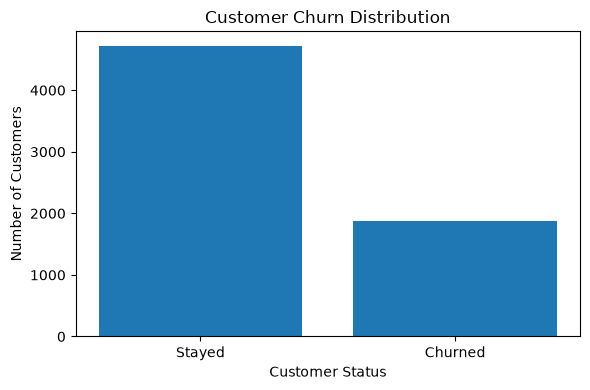

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Stayed", "Churned"],
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Churn by Contract Type

Contract structure may be associated with customer retention. We compare churn rates across month-to-month, one-year, and two-year contracts.

In [12]:
contract_churn = (
    df.groupby("contract")["churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customers",
        "sum": "churned_customers",
        "mean": "churn_rate"
    })
)

contract_churn["churn_rate_pct"] = (
    contract_churn["churn_rate"] * 100
)

contract_churn.sort_values(
    "churn_rate_pct",
    ascending=False
)

,customers,churned_customers,churn_rate,churn_rate_pct
contract,,,,
Month-to-Month,3202,1655.0,0.516864,51.686446
One Year,1526,166.0,0.108781,10.878113
Two Year,1861,48.0,0.025793,2.579258


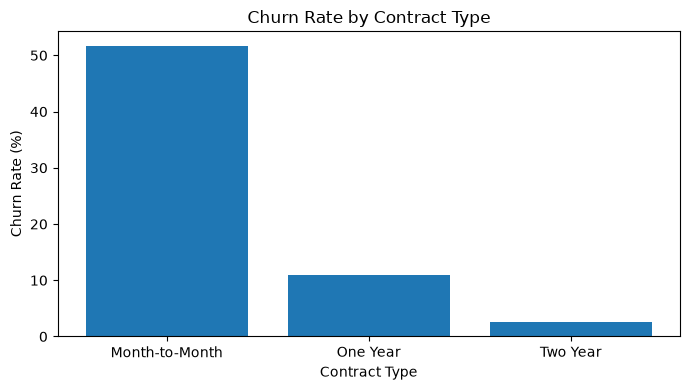

In [13]:
contract_plot = (
    contract_churn["churn_rate_pct"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

plt.bar(
    contract_plot.index,
    contract_plot.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Observation
-Month-to-month customers exhibit substantially higher churn than customers with longer contracts.

## Churn and Customer Tenure

Customer tenure may indicate loyalty and established usage patterns. We examine whether churn risk changes as customers remain with the company longer.

In [14]:
tenure_churn = (
    df.groupby("tenure_months")["churn"]
    .mean()
    .mul(100)
)

tenure_churn.head(10)

tenure_months
1     100.000000
2     100.000000
3     100.000000
4      47.159091
5      48.120301
6      36.363636
7      38.931298
8      34.146341
9      38.655462
10     35.433071
Name: churn, dtype: float64

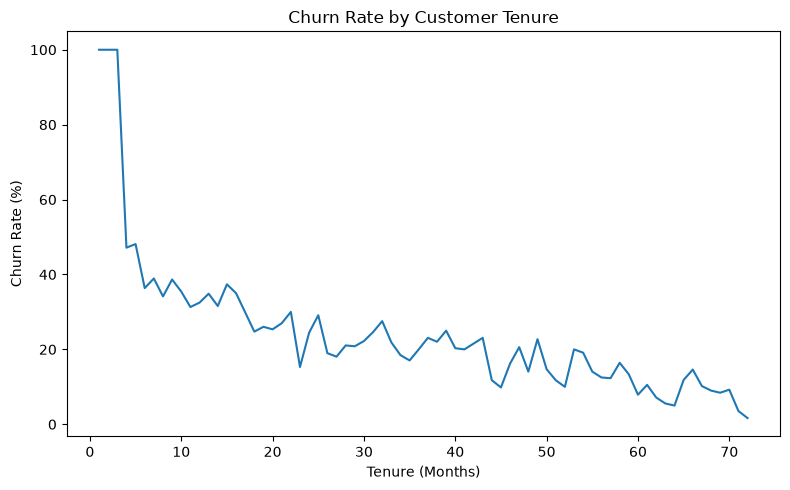

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [16]:
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49+ months"
    ]
)

tenure_group_churn = (
    df.groupby(
        "tenure_group",
        observed=False
    )["churn"]
    .mean()
    .mul(100)
)

tenure_group_churn

tenure_group
0-12 months     59.872979
13-24 months    28.710938
25-48 months    20.388959
49+ months       9.513176
Name: churn, dtype: float64

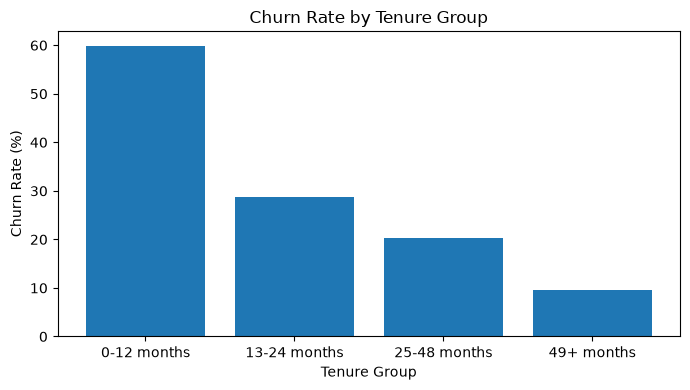

In [17]:
plt.figure(figsize=(7, 4))

plt.bar(
    tenure_group_churn.index.astype(str),
    tenure_group_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## Monthly Charges and Churn

We compare monthly billing between customers who stayed and customers who churned.

Invalid negative monthly charges identified during data cleaning are excluded from this comparison.

In [18]:
df.groupby("churn")["monthly_charge"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0.0,4636.0,62.959362,31.168714,18.25,25.450,66.40,89.75,118.75
1.0,1839.0,74.622974,24.604751,18.85,56.925,79.65,94.25,118.35


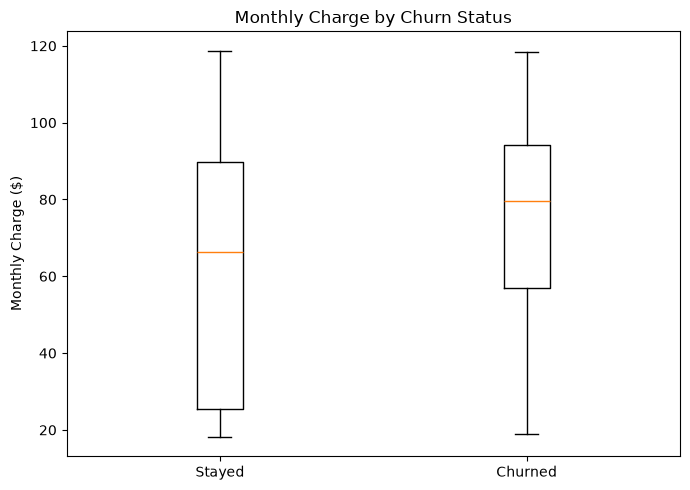

In [19]:
stayed_charges = (
    df.loc[df["churn"] == 0, "monthly_charge"]
    .dropna()
)

churned_charges = (
    df.loc[df["churn"] == 1, "monthly_charge"]
    .dropna()
)

plt.figure(figsize=(7, 5))

plt.boxplot(
    [stayed_charges, churned_charges],
    tick_labels=["Stayed", "Churned"]
)

plt.title("Monthly Charge by Churn Status")
plt.ylabel("Monthly Charge ($)")

plt.tight_layout()
plt.show()

## Premium Technical Support and Churn

Technical support services may be associated with customer satisfaction and retention. Customers without internet service appear as `Not Applicable`.

In [20]:
support_churn = (
    df.groupby("premium_tech_support")["churn"]
    .agg(["count", "mean"])
)

support_churn["churn_rate_pct"] = (
    support_churn["mean"] * 100
)

support_churn.sort_values(
    "churn_rate_pct",
    ascending=False
)

,count,mean,churn_rate_pct
premium_tech_support,,,
No,3248,0.445197,44.519704
Yes,1997,0.155233,15.523285
Not Applicable,1344,0.084077,8.407738


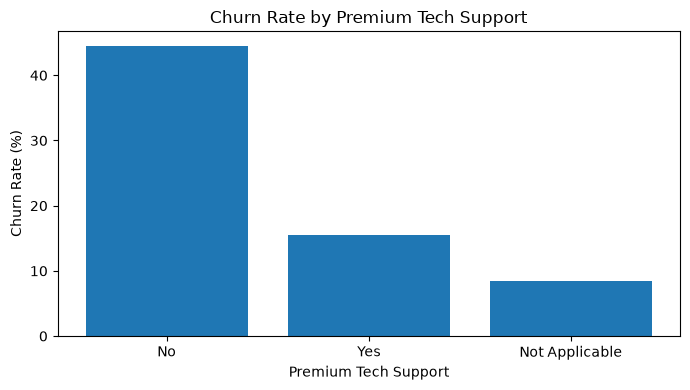

In [21]:
support_plot = (
    support_churn["churn_rate_pct"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

plt.bar(
    support_plot.index,
    support_plot.values
)

plt.title("Churn Rate by Premium Tech Support")
plt.xlabel("Premium Tech Support")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## Internet Type and Churn

We examine whether customers using different internet technologies have different churn rates.

In [22]:
internet_churn = (
    df.groupby("internet_type")["churn"]
    .agg(["count", "mean"])
)

internet_churn["churn_rate_pct"] = (
    internet_churn["mean"] * 100
)

internet_churn.sort_values(
    "churn_rate_pct",
    ascending=False
)

,count,mean,churn_rate_pct
internet_type,,,
Fiber Optic,2934,0.421268,42.126789
Cable,774,0.275194,27.519380
DSL,1537,0.199740,19.973975
Not Applicable,1344,0.084077,8.407738


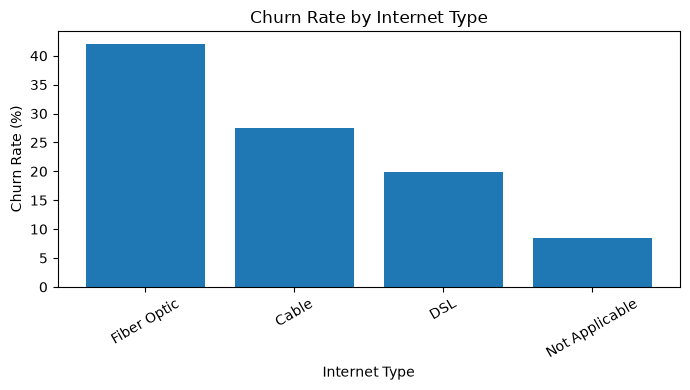

In [23]:
internet_plot = (
    internet_churn["churn_rate_pct"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

plt.bar(
    internet_plot.index,
    internet_plot.values
)

plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Customer Revenue

Total revenue provides a measure of customer financial value. Understanding its distribution will later help develop a retention-priority system that considers both churn probability and customer value.

In [24]:
df["total_revenue"].describe()

count     6589.000000
mean      3235.218082
std       2854.600036
min         21.610000
25%        835.450000
50%       2376.450000
75%       5106.640000
max      11979.340000
Name: total_revenue, dtype: float64

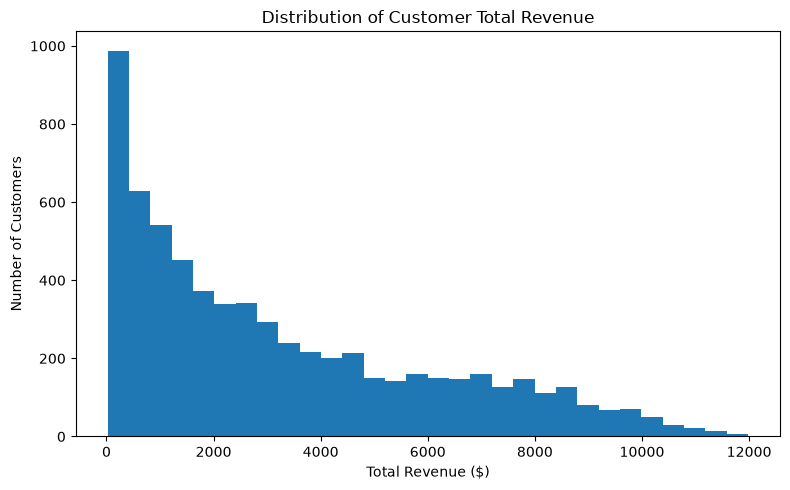

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["total_revenue"],
    bins=30
)

plt.title("Distribution of Customer Total Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [26]:
revenue_by_churn = (
    df.groupby("churn")["total_revenue"]
    .agg(["count", "mean", "median", "sum"])
)

revenue_by_churn.index = [
    "Stayed",
    "Churned"
]

revenue_by_churn

,count,mean,median,sum
Stayed,4720,3735.676297,2960.11,17632392.12
Churned,1869,1971.353569,893.55,3684459.82


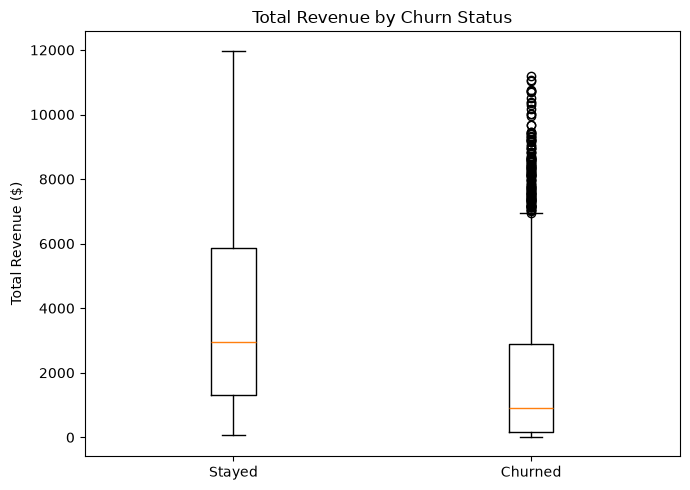

In [27]:
stayed_revenue = df.loc[
    df["churn"] == 0,
    "total_revenue"
]

churned_revenue = df.loc[
    df["churn"] == 1,
    "total_revenue"
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [stayed_revenue, churned_revenue],
    tick_labels=["Stayed", "Churned"]
)

plt.title("Total Revenue by Churn Status")
plt.ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()

## Referrals and Churn

Customers who refer others may represent more engaged or satisfied customers. We examine the relationship between the number of referrals and churn.

In [28]:
df.groupby("churn")["number_of_referrals"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0.0,4720.0,2.614831,3.323925,0.0,0.0,1.0,5.0,11.0
1.0,1869.0,0.521134,1.094667,0.0,0.0,0.0,1.0,9.0


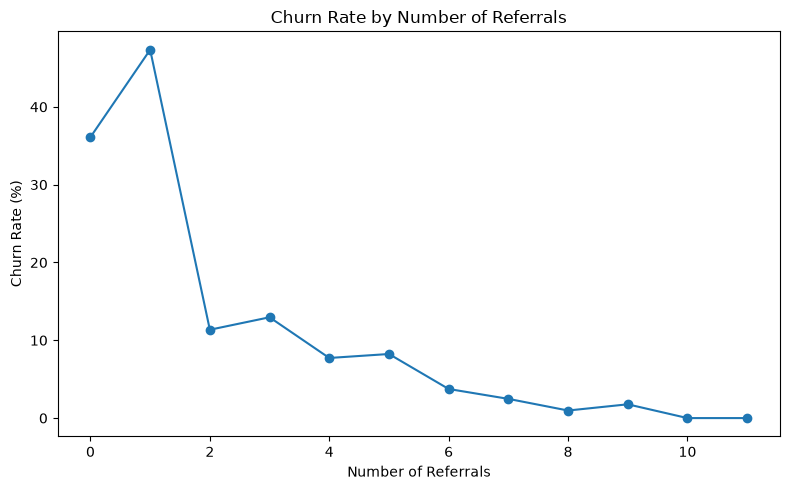

In [29]:
referral_churn = (
    df.groupby("number_of_referrals")["churn"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

plt.plot(
    referral_churn.index,
    referral_churn.values,
    marker="o"
)

plt.title("Churn Rate by Number of Referrals")
plt.xlabel("Number of Referrals")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

## Numerical Feature Correlations

Correlation analysis provides an initial view of relationships among numerical variables. Correlation alone does not establish causation or predictive importance.

In [30]:
numeric_columns = [
    "age",
    "number_of_dependents",
    "number_of_referrals",
    "tenure_months",
    "monthly_charge",
    "total_charges",
    "total_revenue",
    "churn"
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

correlation_matrix

,age,number_of_dependents,number_of_referrals,tenure_months,monthly_charge,total_charges,total_revenue,churn
age,1.000000,-0.125500,-0.032019,-0.009574,0.135339,0.047788,0.035080,0.111174
number_of_dependents,-0.125500,1.000000,0.276880,0.107311,-0.143135,0.016118,0.032315,-0.232525
number_of_referrals,-0.032019,0.276880,1.000000,0.323826,0.012049,0.241943,0.253851,-0.312118
tenure_months,-0.009574,0.107311,0.323826,1.000000,0.204974,0.812795,0.840935,-0.433759
monthly_charge,0.135339,-0.143135,0.012049,0.204974,1.000000,0.648547,0.580927,0.175817
total_charges,0.047788,0.016118,0.241943,0.812795,0.648547,1.000000,0.970266,-0.250071
total_revenue,0.035080,0.032315,0.253851,0.840935,0.580927,0.970266,1.000000,-0.278626
churn,0.111174,-0.232525,-0.312118,-0.433759,0.175817,-0.250071,-0.278626,1.000000


In [31]:
correlation_matrix["churn"].sort_values(
    ascending=False
)

churn                   1.000000
monthly_charge          0.175817
age                     0.111174
number_of_dependents   -0.232525
total_charges          -0.250071
total_revenue          -0.278626
number_of_referrals    -0.312118
tenure_months          -0.433759
Name: churn, dtype: float64

# Preliminary EDA Findings

- Overall churn is approximately 28%.
- Churn is concentrated among newer customers and declines substantially with tenure.
- Month-to-month contracts are associated with substantially greater churn than longer-term contracts.
- Customers without premium technical support exhibit substantially higher churn.
- Fiber-optic customers have the highest churn rate among internet-service types.
- Churned customers tend to have higher monthly charges.
- Customers who stay tend to have more referrals and greater accumulated revenue.
- Tenure and number of referrals show the strongest negative numerical associations with churn.

## Variables for Further Statistical Analysis

- Contract type
- Tenure
- Monthly charge
- Premium technical support
- Internet type
- Number of referrals

These relationships are exploratory associations and should not be interpreted as causal.